This Jupyter notebook was written by Emma T. Swan, April 2026.

This notebook uses data from a dataset posted on 2018-02-02 authored by Rosalind J. Woodworth, Angela O'Brien-Malone, Mark R. Diamond, Benjamin Schüz

This dataset comprises 992 point-in-time records of self-reported happiness and depression in 295 participants, each assigned to one of four intervention groups. Each point-in-time measurement consists of a participant’s responses to the 24 items of the Authentic Happiness Inventory and to the 20 items of the Center for Epidemiological Studies Depression (CES-D) scale. Measurements were sought at the time of each participant’s enrolment in the study (pre-test) and after the intervention (post-test). 

History
2018-02-02 - Posted date

J. Woodworth, Rosalind; O'Brien-Malone, Angela; Diamond, Mark R.; Schüz, Benjamin (2018). A randomized placebo-controlled trial of positive psychology interventions in Australia. figshare. Dataset. https://doi.org/10.6084/m9.figshare.1577563.v1

The data was reformatted to provide a clean dataset for PCA. The pre-test and post-test results are extracted into two columns each for every item. The four intervention groups were kept as categorical variables for between-group comparison. 

# Background

This project aims to validate psychotherapeutic models and assess their effectiveness using analytic methods that accommodate flexible, individualized delivery without sacrificing statistical rigor.
Psychotherapeutic modalities comprise a variety of techniques within the framework of a given theory of practice. These various intervention techniques are typically delivered to clients based on each person's unique needs, capacity, and context. 
However, quantitative research on these therapies has depended on homogeneous delivery across subjects, limiting real-world translation and a better understanding of the therapeutic process. 
Additionally, the extent to which variations in modality delivery across studies have affected research findings remains unclear. 
Is body scanning as central to mindfulness as noticing thoughts without judgment? Is gratitude practice as central to positive psychology as cultivating flow?
An eigenmode analysis lets us quantitatively identify the dominant mode and the variables that load most heavily on its principal components, while still preserving the heterogeneity of real-world modality delivery.

# Research Question

Do the modality-delivery variables (time, interventions, and psychological measures) form a stable eigenmode structure with a dominant eigenvalue that is invariant across interventions, such that any specific technique recovers the same underlying pattern of the psychotherapeutic modality?

# Data Analysis Techniques

This analysis will primarily use PCA and clustering to answer the research question. PCA will help to identify the component with the greatest variance and the dimensions that contribute the greatest weight to the principal components. Clustering will reveal any groupings across dimensions, subjects, and interventions. If there is no consistent pattern or groupings, the analysis will fail to reject the null hypothesis. 

# Load Data

In [298]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

from sklearn.preprocessing import RobustScaler
import pingouin as pg
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm

from sklearn.decomposition import PCA

from sklearn import cluster
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.stats import pearsonr, spearmanr
from scipy.stats import chi2_contingency


from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_samples

expressionData = pd.read_csv("data/Data4.csv")
expressionData

,id,occasion,intervention,ahi01,ahi02,ahi03,ahi04,ahi05,ahi06,ahi07,...,cesd11,cesd12,cesd13,cesd14,cesd15,cesd16,cesd17,cesd18,cesd19,cesd20
0,1,0,4,2,3,2,3,3,2,3,...,3,2,2,3,1,2,1,1,2,2
1,1,1,4,3,3,4,3,3,4,4,...,2,4,1,2,1,3,1,1,1,1
2,2,0,1,3,4,3,4,2,3,4,...,2,4,1,1,1,4,1,1,1,1
3,2,1,1,3,4,4,4,3,3,4,...,1,3,1,1,1,3,1,1,1,1
4,3,0,4,3,3,2,4,2,3,4,...,2,4,1,2,1,4,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,288,1,3,2,3,4,4,3,3,4,...,3,2,4,3,2,2,1,3,2,2
400,289,0,1,2,2,4,2,1,1,2,...,1,1,3,4,1,1,1,4,4,3
401,289,1,1,2,2,4,2,1,1,2,...,1,2,1,2,1,2,1,2,2,2
402,292,0,4,2,2,2,2,2,4,1,...,1,1,2,2,1,3,2,3,1,4


In [299]:
expressionData.columns

Index(['id', 'occasion', 'intervention', 'ahi01', 'ahi02', 'ahi03', 'ahi04',
       'ahi05', 'ahi06', 'ahi07', 'ahi08', 'ahi09', 'ahi10', 'ahi11', 'ahi12',
       'ahi13', 'ahi14', 'ahi15', 'ahi16', 'ahi17', 'ahi18', 'ahi19', 'ahi20',
       'ahi21', 'ahi22', 'ahi23', 'ahi24', 'cesd01', 'cesd02', 'cesd03',
       'cesd04', 'cesd05', 'cesd06', 'cesd07', 'cesd08', 'cesd09', 'cesd10',
       'cesd11', 'cesd12', 'cesd13', 'cesd14', 'cesd15', 'cesd16', 'cesd17',
       'cesd18', 'cesd19', 'cesd20'],
      dtype='str')

# Preliminary Analysis

I ran some initial statistics to get familiar with the data and consider the next steps. 

In [300]:
measurement_cols = [col for col in expressionData.columns if col not in ['id', 'occasion', 'intervention']]
comparisons = [(0, 1)]
for h0, h1 in comparisons:
    print(f"\n=== occasion {h0} vs occasion {h1} (t-test) ===")

    for col in measurement_cols:
        group0 = expressionData.loc[expressionData['occasion'] == h0, col]
        group1 = expressionData.loc[expressionData['occasion'] == h1, col]

        t_stat, p_value = ttest_ind(group0, group1)

        sig = '*' if p_value < 0.05 else ''
        print(f"  {col}: t = {t_stat:.3f}, p = {p_value:.4f} {sig}")


=== occasion 0 vs occasion 1 (t-test) ===
  ahi01: t = -3.301, p = 0.0010 *
  ahi02: t = -2.773, p = 0.0058 *
  ahi03: t = -1.292, p = 0.1971 
  ahi04: t = -0.884, p = 0.3773 
  ahi05: t = -2.537, p = 0.0116 *
  ahi06: t = -0.985, p = 0.3251 
  ahi07: t = -0.673, p = 0.5016 
  ahi08: t = -1.825, p = 0.0687 
  ahi09: t = -1.531, p = 0.1265 
  ahi10: t = -2.318, p = 0.0210 *
  ahi11: t = -1.553, p = 0.1212 
  ahi12: t = 0.000, p = 1.0000 
  ahi13: t = -1.364, p = 0.1734 
  ahi14: t = -2.231, p = 0.0263 *
  ahi15: t = -0.458, p = 0.6474 
  ahi16: t = -1.619, p = 0.1062 
  ahi17: t = -1.876, p = 0.0614 
  ahi18: t = -2.996, p = 0.0029 *
  ahi19: t = 0.685, p = 0.4940 
  ahi20: t = -0.386, p = 0.6994 
  ahi21: t = -2.553, p = 0.0111 *
  ahi22: t = -2.053, p = 0.0407 *
  ahi23: t = -1.535, p = 0.1256 
  ahi24: t = -1.880, p = 0.0609 
  cesd01: t = 2.545, p = 0.0113 *
  cesd02: t = -0.206, p = 0.8373 
  cesd03: t = 1.589, p = 0.1129 
  cesd04: t = -0.347, p = 0.7288 
  cesd05: t = 1.563, p =

In [301]:
measurement_cols = [col for col in expressionData.columns if col not in ['id', 'occasion', 'intervention']]
comparisons = [(0, 1)]
for h0, h1 in comparisons:
    print(f"\n=== occasion {h0} vs occasion {h1} (t-test) ===")

    for col in measurement_cols:
        group0 = expressionData.loc[expressionData['occasion'] == h0, col]
        group1 = expressionData.loc[expressionData['occasion'] == h1, col]

        t_stat, p_value = ttest_ind(group0, group1)

        if p_value < 0.05:
            print(f"  {col}: t = {t_stat:.3f}, p = {p_value:.4f} *")


=== occasion 0 vs occasion 1 (t-test) ===
  ahi01: t = -3.301, p = 0.0010 *
  ahi02: t = -2.773, p = 0.0058 *
  ahi05: t = -2.537, p = 0.0116 *
  ahi10: t = -2.318, p = 0.0210 *
  ahi14: t = -2.231, p = 0.0263 *
  ahi18: t = -2.996, p = 0.0029 *
  ahi21: t = -2.553, p = 0.0111 *
  ahi22: t = -2.053, p = 0.0407 *
  cesd01: t = 2.545, p = 0.0113 *
  cesd07: t = 2.185, p = 0.0295 *
  cesd13: t = 2.541, p = 0.0114 *
  cesd18: t = 2.019, p = 0.0442 *
  cesd20: t = 2.307, p = 0.0216 *


Two tailed t-test score indicate the AHI (happiness) increases from baseline and CESD scores (depression) decrease from baseline. 

In [302]:
measurement_cols = [col for col in expressionData.columns if col not in ['id', 'occasion', 'intervention']]

print("\n=== Mixed Repeated Measures ANOVA (within: occasion, between: intervention) ===\n")

for col in measurement_cols:
    aov = pg.mixed_anova(
        data=expressionData,
        dv=col,
        within='occasion',
        between='intervention',
        subject='id'
    )

    sig_results = aov[aov['p_unc'] < 0.05]

    if not sig_results.empty:
        print(f"--- {col} ---")
        print(sig_results[['Source', 'F', 'p_unc', 'np2']].to_string(index=False))
        print()


=== Mixed Repeated Measures ANOVA (within: occasion, between: intervention) ===

--- ahi01 ---
  Source         F    p_unc      np2
occasion 22.389879 0.000004 0.101592

--- ahi02 ---
  Source         F        p_unc      np2
occasion 25.612255 9.504947e-07 0.114539

--- ahi05 ---
  Source         F    p_unc      np2
occasion 16.434936 0.000072 0.076643

--- ahi08 ---
  Source         F    p_unc      np2
occasion 10.174865 0.001655 0.048877

--- ahi09 ---
  Source       F   p_unc      np2
occasion 5.38829 0.02129 0.026493

--- ahi10 ---
  Source         F    p_unc      np2
occasion 16.735207 0.000063 0.077934

--- ahi11 ---
  Source        F    p_unc      np2
occasion 5.420756 0.020908 0.026648

--- ahi13 ---
      Source        F    p_unc      np2
intervention 3.406412 0.018658 0.049079
    occasion 5.329739 0.021997 0.026212

--- ahi14 ---
  Source         F    p_unc      np2
occasion 13.931123 0.000248 0.065734

--- ahi15 ---
      Source        F    p_unc      np2
intervention 2.86

In [303]:
ahi_cols = [col for col in expressionData.columns if col.startswith('ahi')]
cesd_cols = [col for col in expressionData.columns if col.startswith('cesd')]

expressionData['AHI_total'] = expressionData[ahi_cols].mean(axis=1)
expressionData['CESD_total'] = expressionData[cesd_cols].mean(axis=1)

for col in ['AHI_total', 'CESD_total']:
    print(f"\n=== Mixed ANOVA: {col} ===")
    aov = pg.mixed_anova(
        data=expressionData,
        dv=col,
        within='occasion',
        between='intervention',
        subject='id'
    )
    print(aov[['Source', 'F', 'p_unc', 'np2']].to_string(index=False))


=== Mixed ANOVA: AHI_total ===
      Source         F        p_unc      np2
intervention  0.890200 4.471664e-01 0.013308
    occasion 38.154611 3.644749e-09 0.161566
 Interaction  0.359358 7.824217e-01 0.005415

=== Mixed ANOVA: CESD_total ===
      Source         F    p_unc      np2
intervention  0.809479 0.489970 0.012116
    occasion 12.549011 0.000494 0.059601
 Interaction  0.772637 0.510560 0.011571


In [304]:
ahi_cols = [col for col in expressionData.columns if col.startswith('ahi')]
cesd_cols = [col for col in expressionData.columns if col.startswith('cesd')]

expressionData['AHI_total'] = expressionData[ahi_cols].mean(axis=1)
expressionData['CESD_total'] = expressionData[cesd_cols].mean(axis=1)

pre = expressionData[expressionData['occasion'] == 0][['id', 'intervention', 'AHI_total', 'CESD_total']]
post = expressionData[expressionData['occasion'] == 1][['id', 'AHI_total', 'CESD_total']]

merged = pre.merge(post, on='id', suffixes=('_pre', '_post'))
merged = pd.get_dummies(merged, columns=['intervention'], drop_first=True)

intervention_cols = [col for col in merged.columns if col.startswith('intervention_')]
for target in ['AHI_total_post', 'CESD_total_post']:
    pre_score = target.replace('_post', '_pre')

    X = merged[[pre_score] + intervention_cols]
    y = merged[target]

    model = LinearRegression()
    model.fit(X, y)
    r2 = r2_score(y, model.predict(X))

    print(f"\n=== Linear Regression: predicting {target} ===")
    print(f"  R² = {r2:.4f}")
    print(f"  Intercept: {model.intercept_:.4f}")
    for name, coef in zip(X.columns, model.coef_):
        print(f"  {name}: {coef:.4f}")


=== Linear Regression: predicting AHI_total_post ===
  R² = 0.7245
  Intercept: 0.5327
  AHI_total_pre: 0.8720
  intervention_2: -0.0347
  intervention_3: -0.0498
  intervention_4: -0.0162

=== Linear Regression: predicting CESD_total_post ===
  R² = 0.4407
  Intercept: 0.5370
  CESD_total_pre: 0.6962
  intervention_2: -0.0295
  intervention_3: 0.0352
  intervention_4: -0.0620


In [305]:
merged[intervention_cols] = merged[intervention_cols].astype(int)

for target in ['AHI_total_post', 'CESD_total_post']:
    pre_score = target.replace('_post', '_pre')

    X = merged[[pre_score] + intervention_cols]
    X = sm.add_constant(X)
    y = merged[target]

    model = sm.OLS(y, X).fit()

    print(f"\n=== OLS Regression: predicting {target} ===")
    print(model.summary())


=== OLS Regression: predicting AHI_total_post ===
                            OLS Regression Results                            
Dep. Variable:         AHI_total_post   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     129.5
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           5.23e-54
Time:                        14:48:07   Log-Likelihood:                -44.642
No. Observations:                 202   AIC:                             99.28
Df Residuals:                     197   BIC:                             115.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

# Scale Data

In [306]:
ahi_cols = [col for col in expressionData.columns if col.startswith('ahi')]
cesd_cols = [col for col in expressionData.columns if col.startswith('cesd')]
measurement_cols = ahi_cols + cesd_cols

pre = expressionData[expressionData['occasion'] == 0].set_index('id')
post = expressionData[expressionData['occasion'] == 1].set_index('id')

pre_wide = pre[measurement_cols].add_suffix('_pre')
post_wide = post[measurement_cols].add_suffix('_post')

wide_data = pre_wide.join(post_wide)
wide_data['intervention'] = pre['intervention']

print("Wide data shape:", wide_data.shape)
print(wide_data.head())

Wide data shape: (202, 89)
    ahi01_pre  ahi02_pre  ahi03_pre  ahi04_pre  ahi05_pre  ahi06_pre  \
id                                                                     
1           2          3          2          3          3          2   
2           3          4          3          4          2          3   
3           3          3          2          4          2          3   
4           2          2          3          2          2          3   
5           1          2          3          2          2          2   

    ahi07_pre  ahi08_pre  ahi09_pre  ahi10_pre  ...  cesd12_post  cesd13_post  \
id                                              ...                             
1           3          3          3          2  ...            4            1   
2           4          3          3          3  ...            3            1   
3           4          3          4          3  ...            4            2   
4           3          1          5          2  ...            

In [307]:
all_cols = [c for c in wide_data.columns if c != 'intervention']

log_data = np.log1p(wide_data[all_cols])

robust = RobustScaler()
scaled_wide = pd.DataFrame(
    robust.fit_transform(log_data),
    columns=all_cols,
    index=wide_data.index
)

intervention_dummies = pd.get_dummies(
    wide_data['intervention'], prefix='intervention'
).astype(float)

full_wide = pd.concat([scaled_wide, intervention_dummies], axis=1)

print("Full wide data shape:", full_wide.shape)

Full wide data shape: (202, 92)


In [308]:
normalized = scaled_wide.copy()

print("\n=== Skewness ===")
print(normalized.skew().round(3))

print("\n=== Mean absolute skewness ===")
print(f"  All items: {normalized.skew().abs().mean():.3f}")
print(f"  AHI items: {normalized.filter(like='ahi').skew().abs().mean():.3f}")
print(f"  CESD items: {normalized.filter(like='cesd').skew().abs().mean():.3f}")
print(f"  Pre items: {normalized.filter(like='_pre').skew().abs().mean():.3f}")
print(f"  Post items: {normalized.filter(like='_post').skew().abs().mean():.3f}")


=== Skewness ===
ahi01_pre     -0.631
ahi02_pre     -0.673
ahi03_pre     -0.166
ahi04_pre     -0.827
ahi05_pre      0.058
               ...  
cesd16_post   -1.068
cesd17_post    2.178
cesd18_post    0.902
cesd19_post    1.608
cesd20_post    0.729
Length: 88, dtype: float64

=== Mean absolute skewness ===
  All items: 0.898
  AHI items: 0.809
  CESD items: 1.005
  Pre items: 0.775
  Post items: 1.020


In [309]:
ahi_cols = [col for col in expressionData.columns if col.startswith('ahi')]
cesd_cols = [col for col in expressionData.columns if col.startswith('cesd')]
measurement_cols = ahi_cols + cesd_cols

pre = expressionData[expressionData['occasion'] == 0].set_index('id')
post = expressionData[expressionData['occasion'] == 1].set_index('id')

pre_wide = pre[measurement_cols].add_suffix('_pre')
post_wide = post[measurement_cols].add_suffix('_post')

wide_data = pre_wide.join(post_wide)
wide_data['intervention'] = pre['intervention']

print("Wide data shape:", wide_data.shape)
print("Intervention counts:")
print(wide_data['intervention'].value_counts().sort_index())

Wide data shape: (202, 89)
Intervention counts:
intervention
1    45
2    57
3    44
4    56
Name: count, dtype: int64


# PCA

In [310]:
pca_wide = PCA()
pca_wide.fit(full_wide)

print("=== Eigenvalues and Variance Explained (Wide Format) ===")
eigenvalues = pca_wide.explained_variance_
cumvar = np.cumsum(pca_wide.explained_variance_ratio_)
for i, (ev, vr, cv) in enumerate(zip(eigenvalues,
                                      pca_wide.explained_variance_ratio_,
                                      cumvar)):
    if ev >= 1.0:
        print(f"  PC{i+1}: eigenvalue = {ev:.4f}, variance = {vr*100:.1f}%, cumulative = {cv*100:.1f}%")

print("\n=== PC1 Loadings ===")
pc1_loadings = pd.Series(pca_wide.components_[0], index=full_wide.columns)
print(pc1_loadings.sort_values().round(4))

=== Eigenvalues and Variance Explained (Wide Format) ===
  PC1: eigenvalue = 18.6116, variance = 38.3%, cumulative = 38.3%
  PC2: eigenvalue = 2.8387, variance = 5.8%, cumulative = 44.1%
  PC3: eigenvalue = 2.0928, variance = 4.3%, cumulative = 48.5%
  PC4: eigenvalue = 1.8070, variance = 3.7%, cumulative = 52.2%
  PC5: eigenvalue = 1.6684, variance = 3.4%, cumulative = 55.6%
  PC6: eigenvalue = 1.2176, variance = 2.5%, cumulative = 58.1%
  PC7: eigenvalue = 1.1406, variance = 2.3%, cumulative = 60.5%

=== PC1 Loadings ===
cesd06_pre    -0.1329
cesd18_pre    -0.1217
cesd03_pre    -0.1186
cesd20_post   -0.1163
cesd18_post   -0.1148
                ...  
ahi04_pre      0.1762
ahi18_pre      0.1871
ahi06_pre      0.2124
ahi16_post     0.2193
ahi06_post     0.2200
Length: 92, dtype: float64


In [311]:
all_cols = [c for c in wide_data.columns if c != 'intervention']

pca_results_per_group = {}
loadings_per_group = {}

for group in sorted(wide_data['intervention'].unique()):
    subset = wide_data[wide_data['intervention'] == group][all_cols]

    log_subset = np.log1p(subset)
    scaled_subset = pd.DataFrame(
        RobustScaler().fit_transform(log_subset),
        columns=all_cols,
        index=subset.index
    )

    pca = PCA(n_components=10)
    pca.fit(scaled_subset)

    pca_results_per_group[group] = pca
    loadings_per_group[group] = pd.Series(pca.components_[0], index=all_cols)

    print(f"\n=== Intervention {group} (n={len(subset)}) ===")
    print(f"  PC1 eigenvalue: {pca.explained_variance_[0]:.4f}")
    print(f"  PC1 variance explained: {pca.explained_variance_ratio_[0]*100:.1f}%")

loadings_df = pd.DataFrame(loadings_per_group)
print("\n=== PC1 Loadings Across Interventions (first 10 items) ===")
print(loadings_df.head(10).round(4))


=== Intervention 1 (n=45) ===
  PC1 eigenvalue: 22.1309
  PC1 variance explained: 40.8%

=== Intervention 2 (n=57) ===
  PC1 eigenvalue: 16.3395
  PC1 variance explained: 35.9%

=== Intervention 3 (n=44) ===
  PC1 eigenvalue: 25.6776
  PC1 variance explained: 44.3%

=== Intervention 4 (n=56) ===
  PC1 eigenvalue: 17.7865
  PC1 variance explained: 33.9%

=== PC1 Loadings Across Interventions (first 10 items) ===
                1       2       3       4
ahi01_pre  0.0976  0.1149 -0.1085  0.0868
ahi02_pre  0.1343  0.1008 -0.1067  0.0777
ahi03_pre -0.0179 -0.0023  0.0124  0.0250
ahi04_pre  0.1483  0.1910 -0.1816  0.1562
ahi05_pre  0.0722  0.1406 -0.0446  0.0543
ahi06_pre  0.2106  0.2449 -0.0822  0.1607
ahi07_pre  0.1175  0.1320 -0.1285  0.1920
ahi08_pre  0.0952  0.0954 -0.1480  0.1439
ahi09_pre  0.0704  0.1627 -0.0470  0.1223
ahi10_pre  0.1513  0.1185 -0.0924  0.1116


In [312]:
def tucker_congruence(v1, v2):
    """Tucker's Congruence Coefficient between two loading vectors."""
    return np.dot(v1, v2) / (np.sqrt(np.dot(v1, v1)) * np.sqrt(np.dot(v2, v2)))

groups = sorted(loadings_per_group.keys())
congruence_matrix = pd.DataFrame(index=groups, columns=groups, dtype=float)

for g1 in groups:
    for g2 in groups:
        congruence_matrix.loc[g1, g2] = tucker_congruence(
            loadings_per_group[g1].values,
            loadings_per_group[g2].values
        )

print("\n=== Tucker's Congruence Coefficient Matrix (PC1) ===")
print(congruence_matrix.round(4))

print("\n=== Interpretation Thresholds ===")
print("  > 0.95 : essentially equal (strong evidence of invariance)")
print("  0.85 - 0.95 : fair similarity")
print("  < 0.85 : meaningful difference")


=== Tucker's Congruence Coefficient Matrix (PC1) ===
        1       2       3       4
1  1.0000  0.9296 -0.8481  0.8398
2  0.9296  1.0000 -0.8247  0.8552
3 -0.8481 -0.8247  1.0000 -0.7753
4  0.8398  0.8552 -0.7753  1.0000

=== Interpretation Thresholds ===
  > 0.95 : essentially equal (strong evidence of invariance)
  0.85 - 0.95 : fair similarity
  < 0.85 : meaningful difference


In [313]:
reference = loadings_per_group[1].values
for g in loadings_per_group:
    if np.dot(loadings_per_group[g].values, reference) < 0:
        loadings_per_group[g] = -loadings_per_group[g]

congruence_matrix = pd.DataFrame(index=groups, columns=groups, dtype=float)
for g1 in groups:
    for g2 in groups:
        congruence_matrix.loc[g1, g2] = tucker_congruence(
            loadings_per_group[g1].values,
            loadings_per_group[g2].values
        )

print("=== Tucker's Congruence Coefficient Matrix (PC1) — Sign-Aligned ===")
print(congruence_matrix.round(4))

=== Tucker's Congruence Coefficient Matrix (PC1) — Sign-Aligned ===
        1       2       3       4
1  1.0000  0.9296  0.8481  0.8398
2  0.9296  1.0000  0.8247  0.8552
3  0.8481  0.8247  1.0000  0.7753
4  0.8398  0.8552  0.7753  1.0000


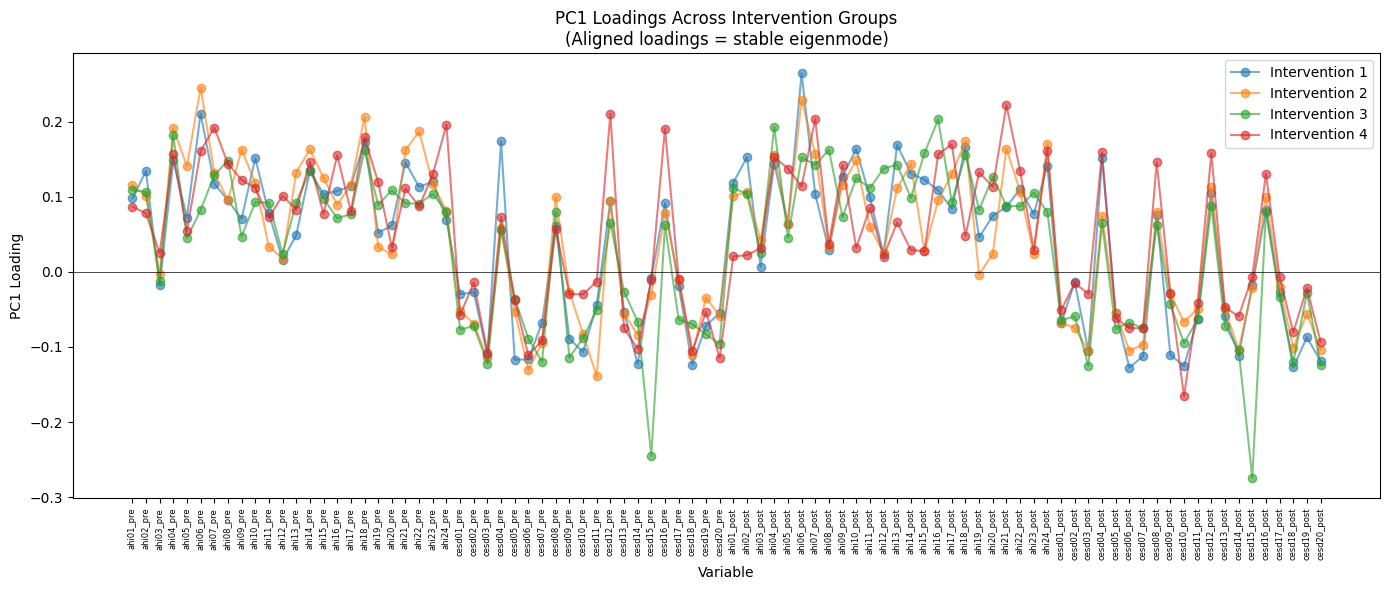

In [314]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, group in enumerate(groups):
    ax.plot(range(len(all_cols)), loadings_per_group[group].values,
            'o-', color=colors[i], alpha=0.6, label=f'Intervention {group}')

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xticks(range(len(all_cols)))
ax.set_xticklabels(all_cols, rotation=90, fontsize=6)
ax.set_xlabel('Variable')
ax.set_ylabel('PC1 Loading')
ax.set_title('PC1 Loadings Across Intervention Groups\n(Aligned loadings = stable eigenmode)')
ax.legend()
plt.tight_layout()
plt.show()

All of the intervention categories are similar and largely congruent, therefore the principal components and underlying pattern holds across delivery methods. 

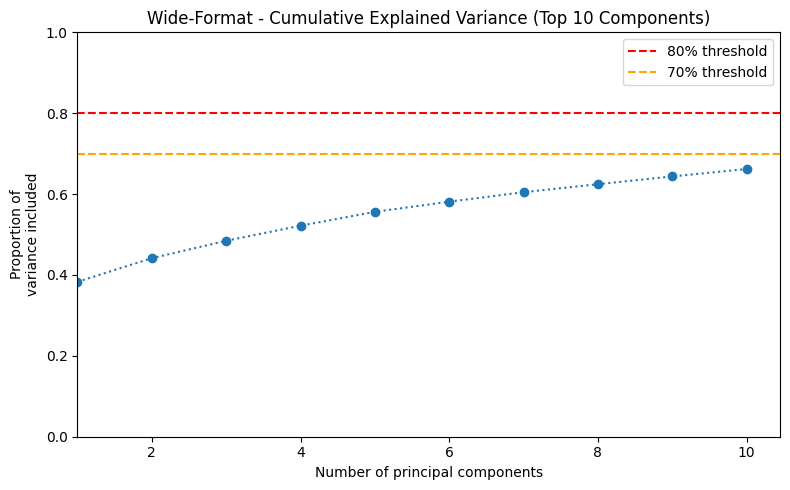

=== Top 10 Components ===
  PC1: eigenvalue = 18.6116, variance = 38.3%, cumulative = 38.3%
  PC2: eigenvalue = 2.8387, variance = 5.8%, cumulative = 44.1%
  PC3: eigenvalue = 2.0928, variance = 4.3%, cumulative = 48.5%
  PC4: eigenvalue = 1.8070, variance = 3.7%, cumulative = 52.2%
  PC5: eigenvalue = 1.6684, variance = 3.4%, cumulative = 55.6%
  PC6: eigenvalue = 1.2176, variance = 2.5%, cumulative = 58.1%
  PC7: eigenvalue = 1.1406, variance = 2.3%, cumulative = 60.5%
  PC8: eigenvalue = 0.9646, variance = 2.0%, cumulative = 62.4%
  PC9: eigenvalue = 0.9289, variance = 1.9%, cumulative = 64.4%
  PC10: eigenvalue = 0.8915, variance = 1.8%, cumulative = 66.2%


In [315]:
all_cols = [c for c in wide_data.columns if c != 'intervention']

log_data = np.log1p(wide_data[all_cols])
scaled_wide = pd.DataFrame(
    RobustScaler().fit_transform(log_data),
    columns=all_cols,
    index=wide_data.index
)

intervention_dummies = pd.get_dummies(
    wide_data['intervention'], prefix='intervention'
).astype(float)

full_wide = pd.concat([scaled_wide, intervention_dummies], axis=1)

n_components = 10
pca_wide = PCA(n_components=n_components)
pca_wide.fit(full_wide)

var_explained_cumulative = pca_wide.explained_variance_ratio_.cumsum()

plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(var_explained_cumulative)) + 1,
         var_explained_cumulative, 'o:')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
plt.axhline(y=0.70, color='orange', linestyle='--', label='70% threshold')
plt.xlabel('Number of principal components')
plt.ylabel('Proportion of\nvariance included')
plt.title('Wide-Format - Cumulative Explained Variance (Top 10 Components)')
plt.legend()
plt.axis(xmin=1, ymax=1, ymin=0)
plt.tight_layout()
plt.show()

print("=== Top 10 Components ===")
for i, (ev, vr, cv) in enumerate(zip(pca_wide.explained_variance_,
                                      pca_wide.explained_variance_ratio_,
                                      var_explained_cumulative)):
    print(f"  PC{i+1}: eigenvalue = {ev:.4f}, variance = {vr*100:.1f}%, cumulative = {cv*100:.1f}%")

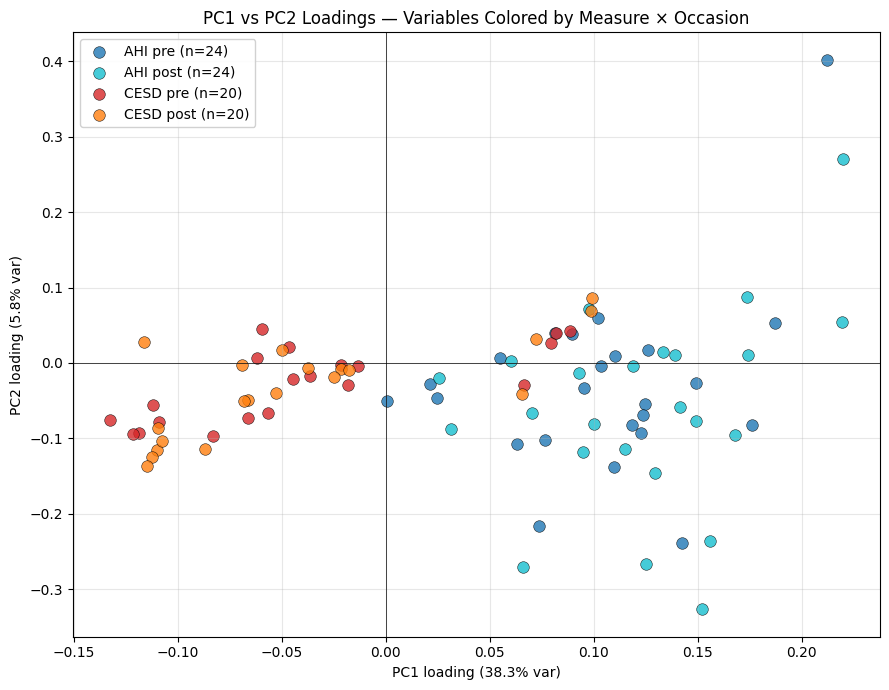

In [316]:
measurement_cols = full_wide.columns.tolist()
loadings = pd.DataFrame({
    'PC1': pca_wide.components_[0],
    'PC2': pca_wide.components_[1],
}, index=measurement_cols)

def classify(name):
    if name.startswith('ahi') and name.endswith('_pre'):   return 'AHI pre'
    if name.startswith('ahi') and name.endswith('_post'):  return 'AHI post'
    if name.startswith('cesd') and name.endswith('_pre'):  return 'CESD pre'
    if name.startswith('cesd') and name.endswith('_post'): return 'CESD post'

loadings['group'] = [classify(c) for c in loadings.index]

color_map = {
    'AHI pre':   '#1f77b4',   
    'AHI post':  '#17becf',   
    'CESD pre':  '#d62728',   
    'CESD post': '#ff7f0e',   
}

plt.figure(figsize=(9, 7))
for grp, color in color_map.items():
    sub = loadings[loadings['group'] == grp]
    plt.scatter(sub['PC1'], sub['PC2'],
                c=color, alpha=0.8, s=70,
                edgecolor='black', linewidth=0.4,
                label=f'{grp} (n={len(sub)})')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel(f"PC1 loading ({pca_wide.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 loading ({pca_wide.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PC1 vs PC2 Loadings — Variables Colored by Measure × Occasion")
plt.legend(loc='best', framealpha=0.9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [317]:
measurement_cols = full_wide.columns.tolist()

component1 = pd.Series(pca_wide.components_[0], index=measurement_cols)
print("=== PC1 Loadings (all variables) ===")
print(component1)

print("\n=== PC1 Loadings sorted by |magnitude| (top 20) ===")
print(component1.reindex(component1.abs().sort_values(ascending=False).index).head(20))

print("\n=== Mean |loading| by block ===")
ahi_pre  = component1.filter(like='ahi').filter(like='_pre').abs().mean()
ahi_post = component1.filter(like='ahi').filter(like='_post').abs().mean()
ces_pre  = component1.filter(like='cesd').filter(like='_pre').abs().mean()
ces_post = component1.filter(like='cesd').filter(like='_post').abs().mean()
print(f"AHI pre : {ahi_pre:.4f}")
print(f"AHI post: {ahi_post:.4f}")
print(f"CESD pre : {ces_pre:.4f}")
print(f"CESD post: {ces_post:.4f}")

=== PC1 Loadings (all variables) ===
ahi01_pre         0.103677
ahi02_pre         0.110183
ahi03_pre         0.000719
ahi04_pre         0.176209
ahi05_pre         0.054896
                    ...   
cesd20_post      -0.116310
intervention_1   -0.007145
intervention_2   -0.002726
intervention_3   -0.001476
intervention_4    0.011347
Length: 92, dtype: float64

=== PC1 Loadings sorted by |magnitude| (top 20) ===
ahi06_post    0.220020
ahi16_post    0.219319
ahi06_pre     0.212404
ahi18_pre     0.187066
ahi04_pre     0.176209
ahi18_post    0.174007
ahi24_post    0.173719
ahi04_post    0.167892
ahi07_post    0.155709
ahi15_post    0.151944
ahi14_pre     0.149391
ahi14_post    0.149149
ahi07_pre     0.142631
ahi10_post    0.141246
ahi01_post    0.139158
ahi08_post    0.133265
cesd06_pre   -0.132876
ahi13_post    0.129247
ahi08_pre     0.126051
ahi20_post    0.125188
dtype: float64

=== Mean |loading| by block ===
AHI pre : 0.1037
AHI post: 0.1230
CESD pre : 0.0710
CESD post: 0.0751


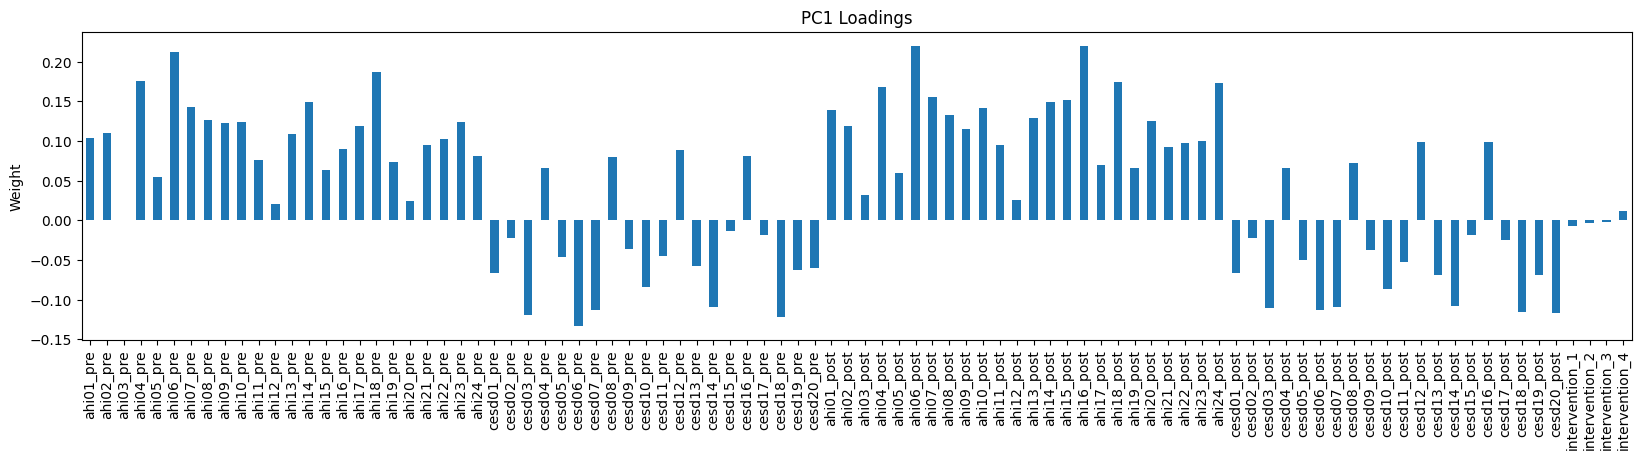

In [318]:
plt.figure(figsize=(20, 4))

component1.plot.bar()

plt.ylabel('Weight')

plt.title('PC1 Loadings')

plt.show()

In [319]:
abs(component1).sort_values()

ahi03_pre         0.000719
intervention_3    0.001476
intervention_2    0.002726
intervention_1    0.007145
intervention_4    0.011347
                    ...   
ahi04_pre         0.176209
ahi18_pre         0.187066
ahi06_pre         0.212404
ahi16_post        0.219319
ahi06_post        0.220020
Length: 92, dtype: float64

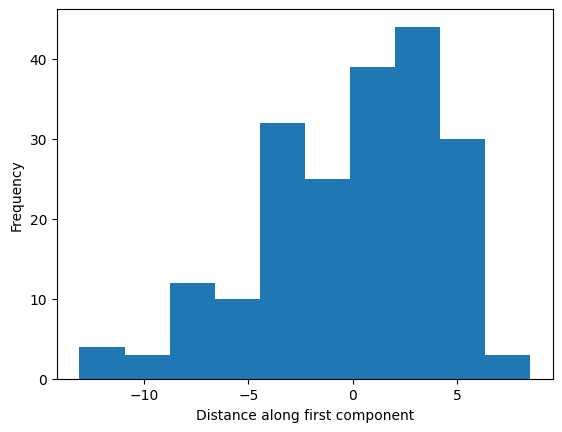

In [320]:
data_along_component1 = pca_wide.transform(full_wide)[:, 0]

plt.hist(data_along_component1, bins=10)

plt.xlabel('Distance along first component')

plt.ylabel('Frequency')

plt.show()

# Clustering

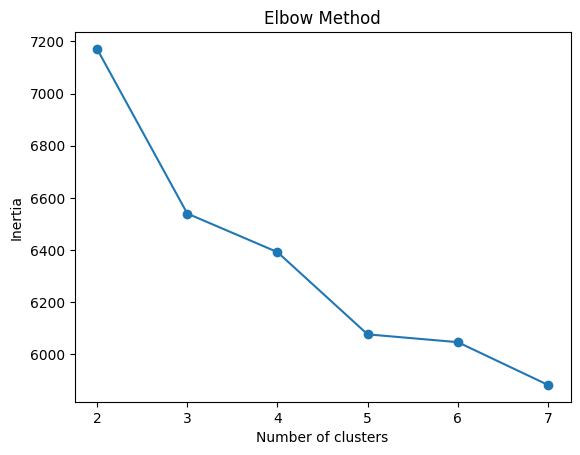

In [321]:
inertias = []
k_range = range(2, 8)

for k in k_range:
    km = cluster.KMeans(n_clusters=k, random_state=42).fit(full_wide)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

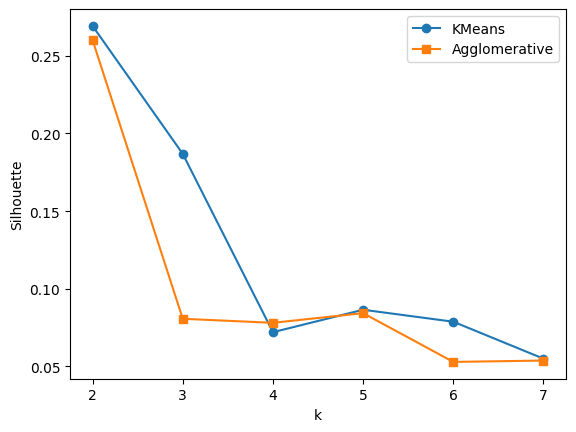

KMeans:         {2: np.float64(0.269), 3: np.float64(0.187), 4: np.float64(0.072), 5: np.float64(0.087), 6: np.float64(0.079), 7: np.float64(0.055)}
Agglomerative:  {2: np.float64(0.26), 3: np.float64(0.081), 4: np.float64(0.078), 5: np.float64(0.084), 6: np.float64(0.053), 7: np.float64(0.054)}


In [326]:
k_range = range(2, 8)
sil_km, sil_ag = [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(full_wide)
    ag = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(full_wide)
    sil_km.append(silhouette_score(full_wide, km.labels_))
    sil_ag.append(silhouette_score(full_wide, ag.labels_))

plt.plot(list(k_range), sil_km, 'o-', label='KMeans')
plt.plot(list(k_range), sil_ag, 's-', label='Agglomerative')
plt.xlabel('k'); plt.ylabel('Silhouette'); plt.legend(); plt.show()

print("KMeans:        ", dict(zip(k_range, np.round(sil_km, 3))))
print("Agglomerative: ", dict(zip(k_range, np.round(sil_ag, 3))))

In [327]:
k = 2
kmeans_results = KMeans(n_clusters=k, n_init=20, random_state=42).fit(full_wide)
ac_results     = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(full_wide)

ari = adjusted_rand_score(kmeans_results.labels_, ac_results.labels_)
print(f"ARI (KMeans vs Agglomerative, k={k}): {ari:.3f}")

ARI (KMeans vs Agglomerative, k=2): 0.620


In [328]:
ahi_items  = [c.replace('_pre','') for c in full_wide.columns
              if c.startswith('ahi') and c.endswith('_pre')]
cesd_items = [c.replace('_pre','') for c in full_wide.columns
              if c.startswith('cesd') and c.endswith('_pre')]

def corr_table(items, label):
    rows = []
    for it in items:
        pre, post = full_wide[f'{it}_pre'], full_wide[f'{it}_post']
        rows.append((it,
                     pearsonr(pre, post)[0],
                     pearsonr(pre, post - pre)[0]))
    df = pd.DataFrame(rows, columns=['item', 'r_pre_post', 'r_pre_change'])
    print(f"\n{label}:\n", df.describe().loc[['mean','std','min','max']].round(3))
    return df

ahi_corr  = corr_table(ahi_items,  'AHI items')
cesd_corr = corr_table(cesd_items, 'CESD items')


AHI items:
       r_pre_post  r_pre_change
mean       0.651        -0.348
std        0.075         0.346
min        0.519        -0.848
max        0.761         0.411

CESD items:
       r_pre_post  r_pre_change
mean       0.553        -0.448
std        0.105         0.130
min        0.326        -0.609
max        0.703         0.036


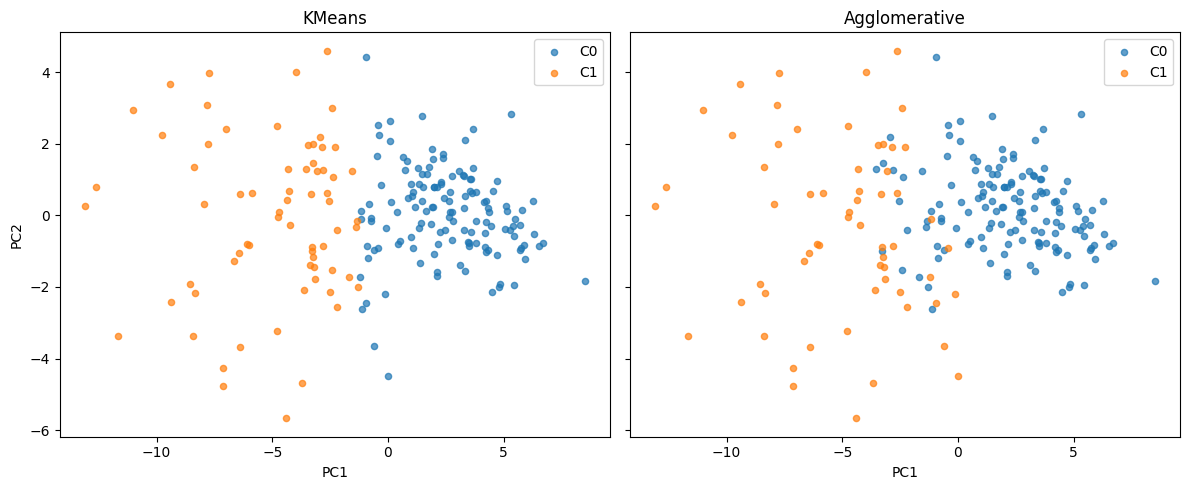

In [329]:
pcs = PCA(n_components=2).fit_transform(full_wide)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for c in np.unique(kmeans_results.labels_):
    m = kmeans_results.labels_ == c
    ax[0].scatter(pcs[m,0], pcs[m,1], s=20, alpha=0.7, label=f'C{c}')
ax[0].set_title('KMeans'); ax[0].set_xlabel('PC1'); ax[0].set_ylabel('PC2'); ax[0].legend()

for c in np.unique(ac_results.labels_):
    m = ac_results.labels_ == c
    ax[1].scatter(pcs[m,0], pcs[m,1], s=20, alpha=0.7, label=f'C{c}')
ax[1].set_title('Agglomerative'); ax[1].set_xlabel('PC1'); ax[1].legend()
plt.tight_layout(); plt.show()

In [330]:
df = full_wide.copy()
df['kmeans_cluster'] = kmeans_results.labels_
df['agglom_cluster'] = ac_results.labels_

print("K-means cluster profiles:")
print(df.groupby('kmeans_cluster')[full_wide.columns].mean().round(3))
print("\nAgglomerative cluster profiles:")
print(df.groupby('agglom_cluster')[full_wide.columns].mean().round(3))

intervention = expressionData.drop_duplicates('id').set_index('id')['intervention']
intervention = intervention.reindex(full_wide.index)

print("\nKMeans x intervention:\n", pd.crosstab(intervention, kmeans_results.labels_, margins=True))
print("\nAgglomerative x intervention:\n", pd.crosstab(intervention, ac_results.labels_, margins=True))

K-means cluster profiles:
                ahi01_pre  ahi02_pre  ahi03_pre  ahi04_pre  ahi05_pre  \
kmeans_cluster                                                          
0                   -0.19     -0.101     -0.427     -0.243     -0.037   
1                   -0.96     -1.039     -0.379     -1.496     -0.399   

                ahi06_pre  ahi07_pre  ahi08_pre  ahi09_pre  ahi10_pre  ...  \
kmeans_cluster                                                         ...   
0                   0.295      0.525     -0.061      0.561     -0.115  ...   
1                  -1.144     -0.522     -0.985     -0.311     -1.173  ...   

                cesd15_post  cesd16_post  cesd17_post  cesd18_post  \
kmeans_cluster                                                       
0                     0.051        0.289        0.041        0.293   
1                     0.191       -0.513        0.235        1.131   

                cesd19_post  cesd20_post  intervention_1  intervention_2  \
kmeans_clus

The clusters do not differ by delivery modality. This agrees with the Tucker's congruence and mixed ANOVA already applied. The underlying pattern structure is invariant across interventions indicating the modality is not what the clusters are tracking.

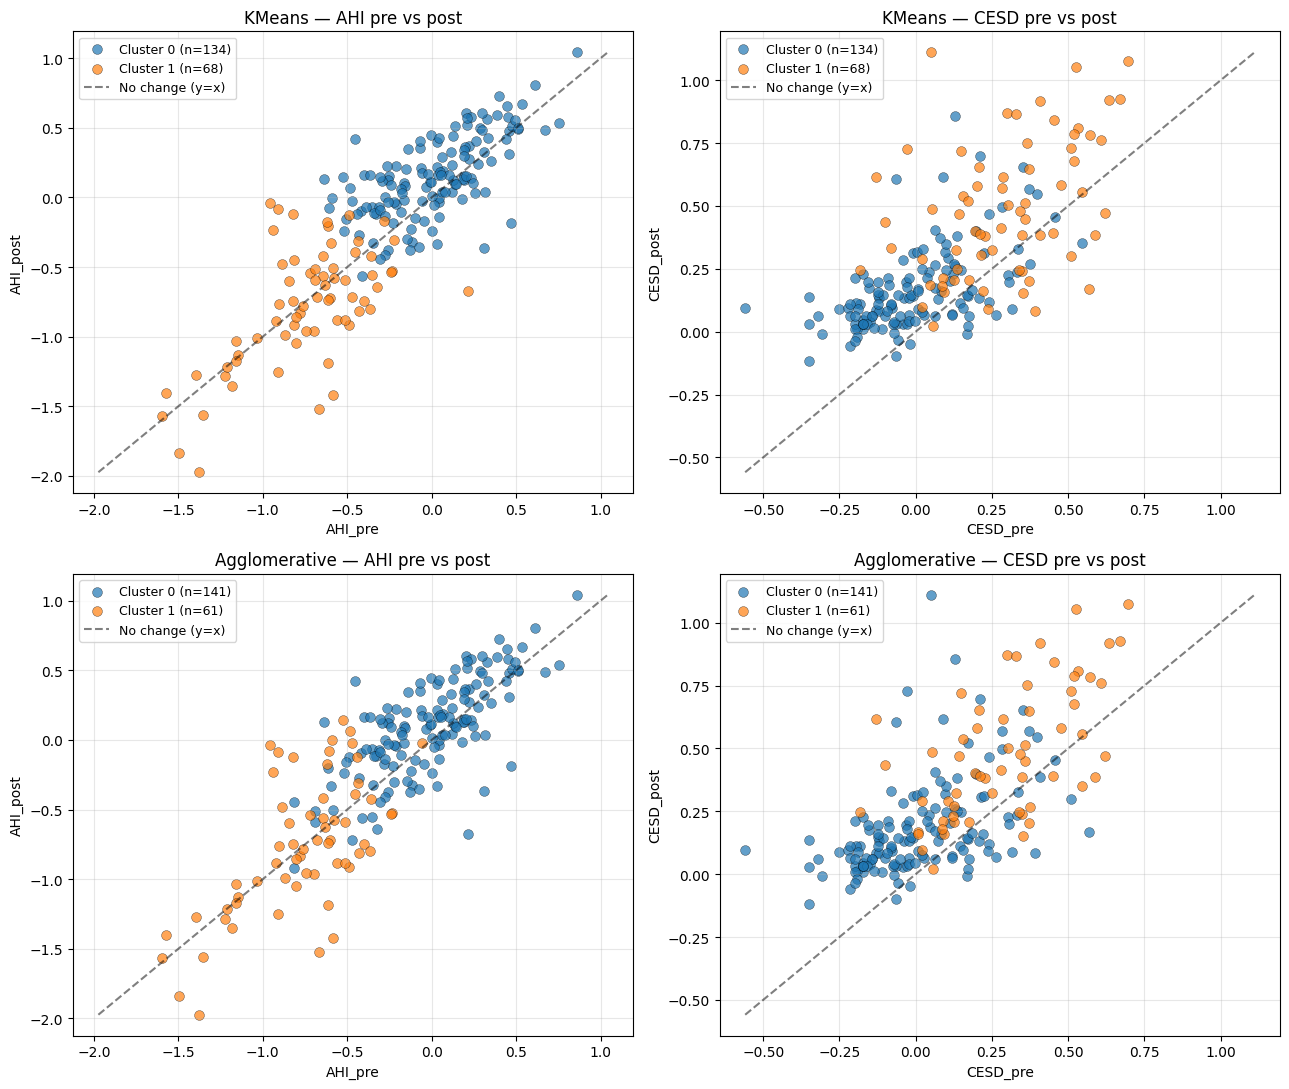

In [331]:
colors = ['#1f77b4', '#ff7f0e']

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

def pre_post_scatter(ax, xcol, ycol, labels, title):
    for c in sorted(profile[labels].unique()):
        sub = profile[profile[labels] == c]
        ax.scatter(sub[xcol], sub[ycol], c=colors[c], alpha=0.7, s=50,
                   edgecolor='black', linewidth=0.3,
                   label=f'Cluster {c} (n={len(sub)})')
    lo = min(profile[xcol].min(), profile[ycol].min())
    hi = max(profile[xcol].max(), profile[ycol].max())
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='No change (y=x)')
    ax.set_xlabel(xcol); ax.set_ylabel(ycol); ax.set_title(title)
    ax.legend(loc='best', fontsize=9); ax.grid(alpha=0.3)

pre_post_scatter(axes[0, 0], 'AHI_pre',  'AHI_post',  'km_cluster',  'KMeans — AHI pre vs post')
pre_post_scatter(axes[0, 1], 'CESD_pre', 'CESD_post', 'km_cluster',  'KMeans — CESD pre vs post')
pre_post_scatter(axes[1, 0], 'AHI_pre',  'AHI_post',  'agg_cluster', 'Agglomerative — AHI pre vs post')
pre_post_scatter(axes[1, 1], 'CESD_pre', 'CESD_post', 'agg_cluster', 'Agglomerative — CESD pre vs post')

plt.tight_layout()
plt.show()

Both clusters hug the no-change line. This indicates that neither cluster is characterized by bigger change but rather, they're characterized by where on the scale the person sits so that their baseline severity is predictive rather than treatment response. This is consistent for both psychological instruments and for the two types of clustering (kmeans and agglomerative).  

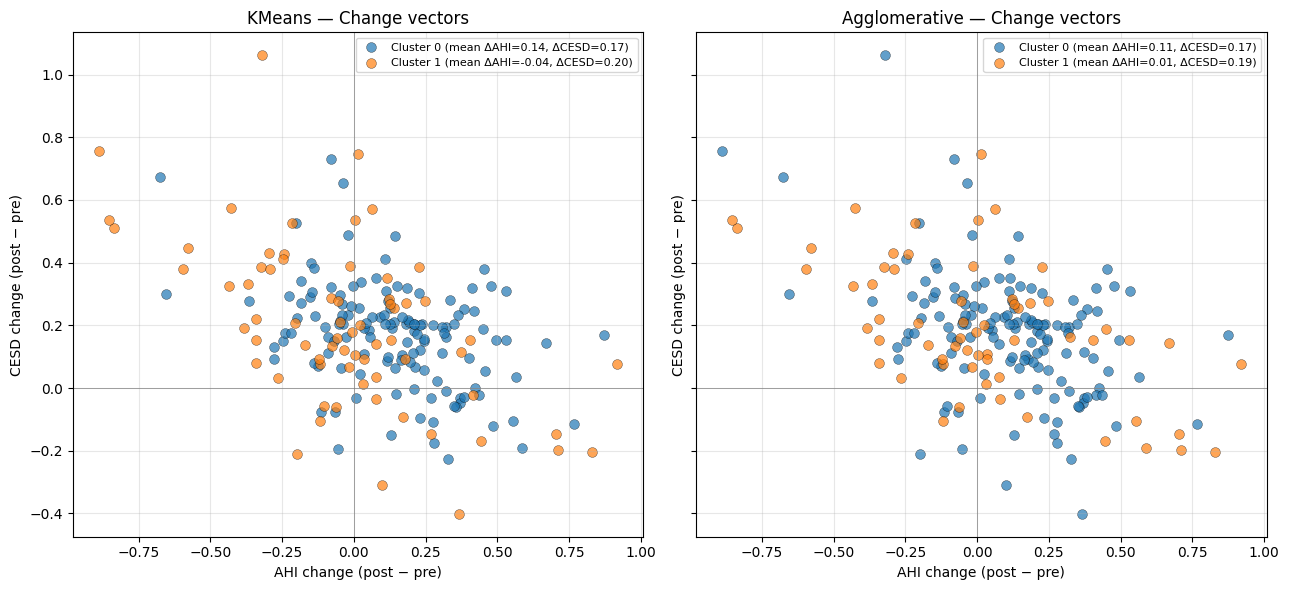

In [332]:
colors = ['#1f77b4', '#ff7f0e']

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

def change_scatter(ax, labels, title):
    for c in sorted(profile[labels].unique()):
        sub = profile[profile[labels] == c]
        ax.scatter(sub['AHI_change'], sub['CESD_change'],
                   c=colors[c], alpha=0.7, s=50,
                   edgecolor='black', linewidth=0.3,
                   label=f'Cluster {c} (mean ΔAHI={sub.AHI_change.mean():.2f}, ΔCESD={sub.CESD_change.mean():.2f})')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel('AHI change (post − pre)')
    ax.set_ylabel('CESD change (post − pre)')
    ax.set_title(title); ax.legend(loc='best', fontsize=8); ax.grid(alpha=0.3)

change_scatter(axes[0], 'km_cluster',  'KMeans — Change vectors')
change_scatter(axes[1], 'agg_cluster', 'Agglomerative — Change vectors')

plt.tight_layout()
plt.show()

Again, these plots confirm that change is not significant to clusters.

In [333]:
for name, labels in [('KMeans', kmeans_results.labels_),
                     ('Agglomerative', ac_results.labels_)]:
    tab = pd.crosstab(intervention, labels)
    chi2, p, dof, _ = chi2_contingency(tab)
    print(f"{name}: chi2 = {chi2:.3f}, dof = {dof}, p = {p:.4f}")

KMeans: chi2 = 2.051, dof = 3, p = 0.5619
Agglomerative: chi2 = 0.935, dof = 3, p = 0.8170


In [334]:
ahi_pre   = full_wide[[c for c in full_wide.columns if c.startswith('ahi')  and c.endswith('_pre')]].mean(axis=1)
ahi_post  = full_wide[[c for c in full_wide.columns if c.startswith('ahi')  and c.endswith('_post')]].mean(axis=1)
cesd_pre  = full_wide[[c for c in full_wide.columns if c.startswith('cesd') and c.endswith('_pre')]].mean(axis=1)
cesd_post = full_wide[[c for c in full_wide.columns if c.startswith('cesd') and c.endswith('_post')]].mean(axis=1)

profile = pd.DataFrame({
    'AHI_pre':     ahi_pre,
    'AHI_post':    ahi_post,
    'AHI_change':  ahi_post - ahi_pre,
    'CESD_pre':    cesd_pre,
    'CESD_post':   cesd_post,
    'CESD_change': cesd_post - cesd_pre,
    'km_cluster':  kmeans_results.labels_,
    'agg_cluster': ac_results.labels_,
})

print("KMeans cluster profile:")
print(profile.groupby('km_cluster').mean().round(3))
print("\nAgglomerative cluster profile:")
print(profile.groupby('agg_cluster').mean().round(3))

KMeans cluster profile:
            AHI_pre  AHI_post  AHI_change  CESD_pre  CESD_post  CESD_change  \
km_cluster                                                                    
0             0.011     0.147       0.137    -0.005      0.164        0.169   
1            -0.744    -0.781      -0.037     0.289      0.487        0.198   

            agg_cluster  
km_cluster               
0                 0.052  
1                 0.794  

Agglomerative cluster profile:
             AHI_pre  AHI_post  AHI_change  CESD_pre  CESD_post  CESD_change  \
agg_cluster                                                                    
0             -0.015     0.093       0.108     0.008      0.180        0.172   
1             -0.772    -0.762       0.010     0.292      0.487        0.194   

             km_cluster  
agg_cluster              
0                 0.099  
1                 0.885  


The chi-square tests show no relationship between cluster membership and intervention. The profile table shows Cluster 1 to consist of people whose baseline was lower in happiness and higher in depression, and both clusters improved by similar magnitudes. Kmeans and agglomerative are largely identifying the same underlying grouping, with some boundary cases accounting for the ARI of 0.62. 

# t-SNE

In [335]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=42)
emb = tsne.fit_transform(full_wide)

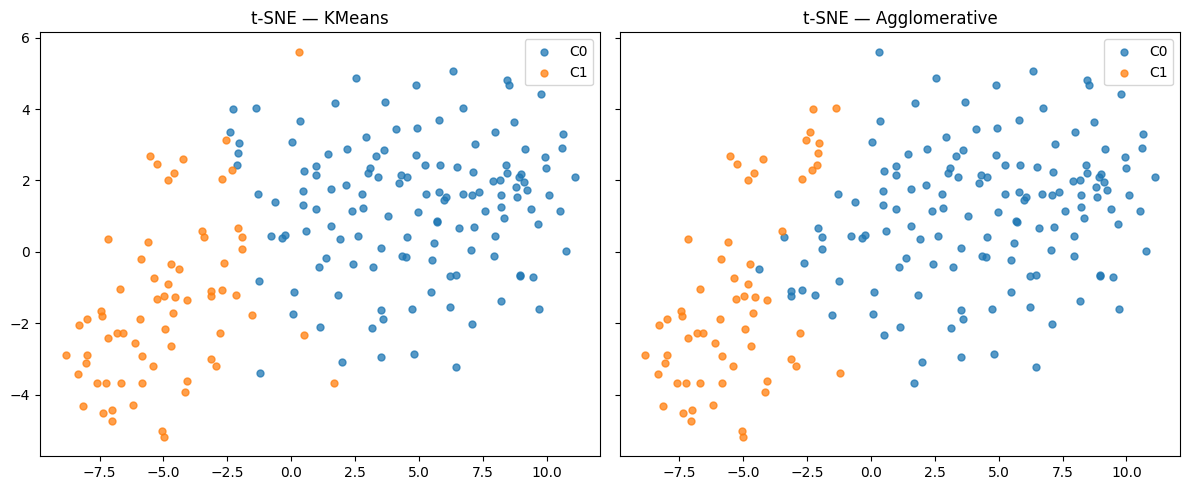

In [336]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for c in np.unique(kmeans_results.labels_):
    m = kmeans_results.labels_ == c
    ax[0].scatter(emb[m, 0], emb[m, 1], s=25, alpha=0.75, label=f'C{c}')
ax[0].set_title('t-SNE — KMeans'); ax[0].legend()

for c in np.unique(ac_results.labels_):
    m = ac_results.labels_ == c
    ax[1].scatter(emb[m, 0], emb[m, 1], s=25, alpha=0.75, label=f'C{c}')
ax[1].set_title('t-SNE — Agglomerative'); ax[1].legend()

plt.tight_layout(); plt.show()

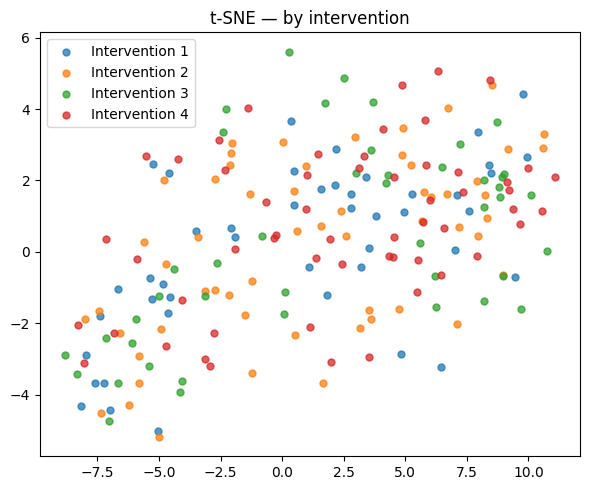

In [337]:
plt.figure(figsize=(6, 5))
for iv in sorted(intervention.unique()):
    m = (intervention.values == iv)
    plt.scatter(emb[m, 0], emb[m, 1], s=25, alpha=0.75, label=f'Intervention {iv}')
plt.title('t-SNE — by intervention'); plt.legend()
plt.tight_layout(); plt.show()

# Eigenmode

In [338]:
cov = np.cov(full_wide.values, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(cov)

order   = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

print("Top 10 eigenvalues:", np.round(eigvals[:10], 3))
print("Variance explained:", np.round(eigvals[:10] / eigvals.sum(), 3))
print("Cumulative:        ", np.round(np.cumsum(eigvals[:10] / eigvals.sum()), 3))

Top 10 eigenvalues: [18.612  2.839  2.093  1.807  1.668  1.218  1.141  0.965  0.929  0.891]
Variance explained: [0.383 0.058 0.043 0.037 0.034 0.025 0.023 0.02  0.019 0.018]
Cumulative:         [0.383 0.441 0.485 0.522 0.556 0.581 0.605 0.624 0.644 0.662]


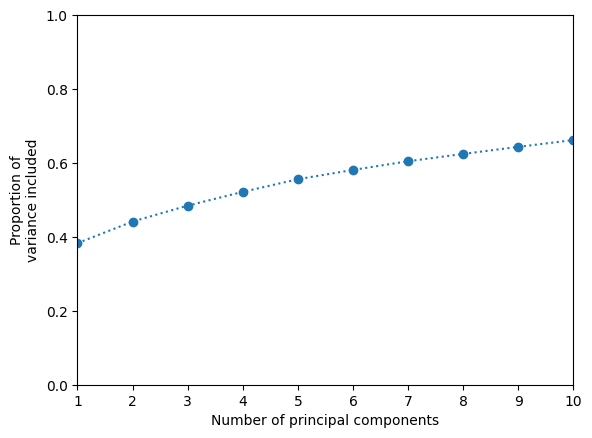

In [347]:
n_show = 10
var_explained_cumulative = eigvals[:n_show].cumsum() / eigvals.sum()

plt.plot(np.arange(n_show) + 1, var_explained_cumulative, 'o:')
plt.xlabel('Number of principal components')
plt.ylabel('Proportion of\nvariance included')
plt.axis(xmin=1, xmax=n_show, ymin=0, ymax=1)
plt.show()

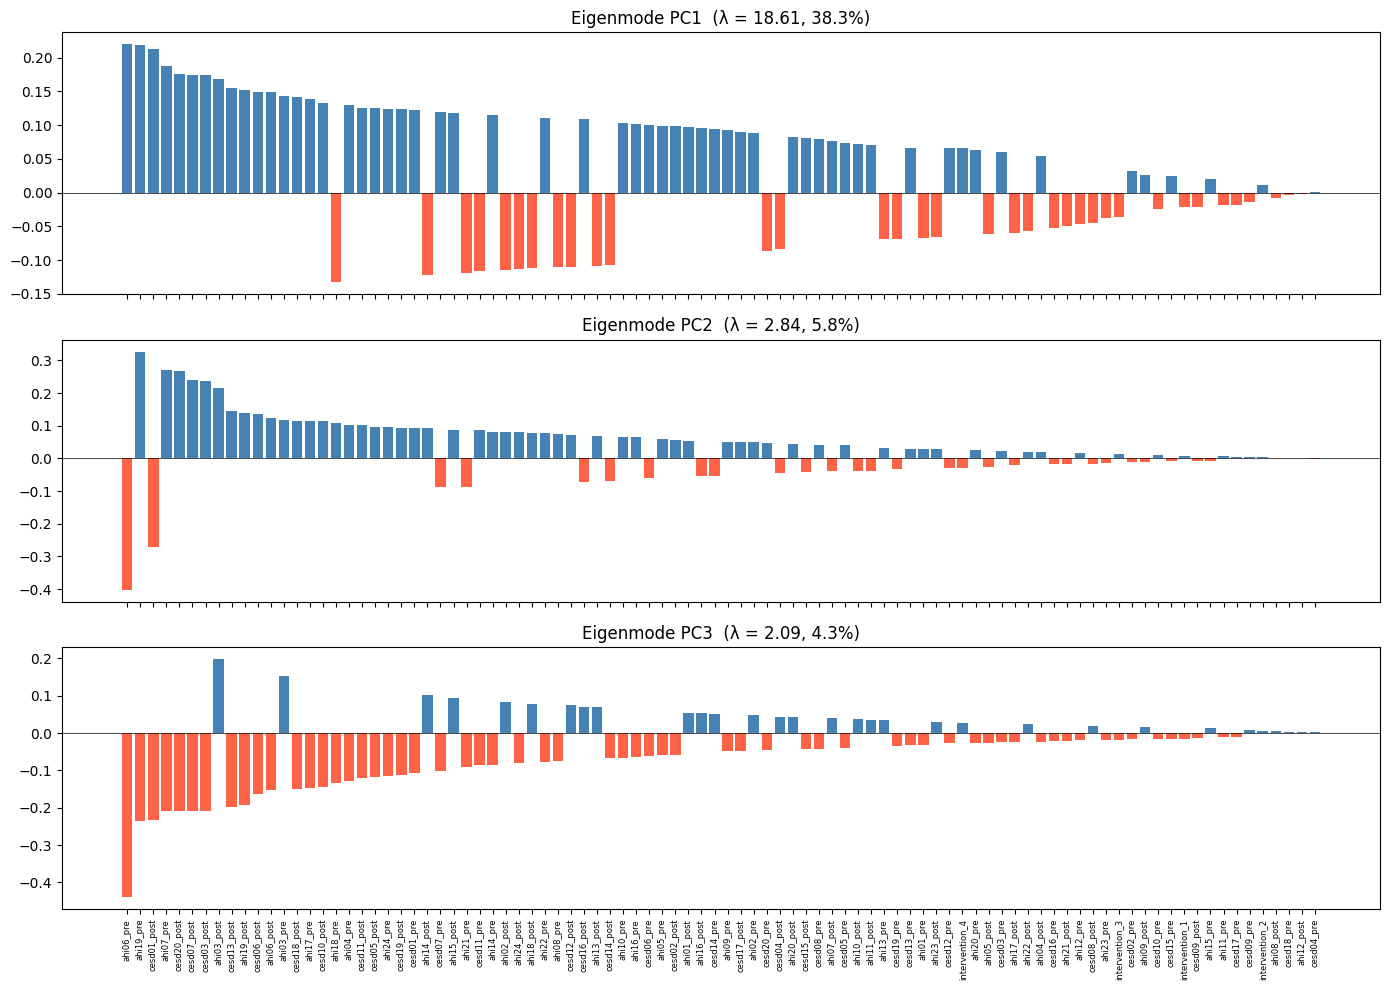

In [340]:
feat = full_wide.columns.values

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for i, ax in enumerate(axes):
    v = eigvecs[:, i]
    idx = np.argsort(np.abs(v))[::-1]
    ax.bar(range(len(v)), v[idx], color=['steelblue' if x >= 0 else 'tomato' for x in v[idx]])
    ax.set_title(f'Eigenmode PC{i+1}  (λ = {eigvals[i]:.2f}, {eigvals[i]/eigvals.sum()*100:.1f}%)')
    ax.set_xticks(range(len(v)))
    ax.set_xticklabels(feat[idx], rotation=90, fontsize=6)
    ax.axhline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

In [346]:
print("Kaiser criterion (eigenvalue > 1.0):")
for i, ev in enumerate(eigvals):
    sig = "Significant" if ev > 1.0 else "Not significant"
    print(f"PC{i+1}: {ev:.4f} - {sig}")

Kaiser criterion (eigenvalue > 1.0):
PC1: 18.6116 - Significant
PC2: 2.8387 - Significant
PC3: 2.0928 - Significant
PC4: 1.8070 - Significant
PC5: 1.6684 - Significant
PC6: 1.2176 - Significant
PC7: 1.1406 - Significant
PC8: 0.9646 - Not significant
PC9: 0.9289 - Not significant
PC10: 0.8915 - Not significant
PC11: 0.8206 - Not significant
PC12: 0.7926 - Not significant
PC13: 0.7402 - Not significant
PC14: 0.6939 - Not significant
PC15: 0.6022 - Not significant
PC16: 0.5785 - Not significant
PC17: 0.5464 - Not significant
PC18: 0.5390 - Not significant
PC19: 0.5151 - Not significant
PC20: 0.4894 - Not significant
PC21: 0.4657 - Not significant
PC22: 0.4525 - Not significant
PC23: 0.4137 - Not significant
PC24: 0.4077 - Not significant
PC25: 0.3733 - Not significant
PC26: 0.3663 - Not significant
PC27: 0.3401 - Not significant
PC28: 0.3299 - Not significant
PC29: 0.3187 - Not significant
PC30: 0.3074 - Not significant
PC31: 0.2950 - Not significant
PC32: 0.2863 - Not significant
PC33: 0

In [344]:
n_obs, n_vars = full_wide.shape
n_iterations = 1000

random_eigenvalues = np.zeros((n_iterations, n_vars))
for i in range(n_iterations):
    random_data = np.random.normal(size=(n_obs, n_vars))
    cov_matrix = np.corrcoef(random_data, rowvar=False)
    random_eigenvalues[i] = np.sort(np.linalg.eigvalsh(cov_matrix))[::-1]

mean_random = random_eigenvalues.mean(axis=0)
p95_random  = np.percentile(random_eigenvalues, 95, axis=0)

print("Component | Actual Eigenvalue | Mean Random | 95th Percentile | Significant?")
print("-" * 80)
for i in range(n_vars):
    sig = "Yes" if eigvals[i] > p95_random[i] else "No"
    print(f"PC{i+1:>2}      | {eigvals[i]:>16.4f} | {mean_random[i]:>11.4f} | {p95_random[i]:>15.4f} | {sig}")

Component | Actual Eigenvalue | Mean Random | 95th Percentile | Significant?
--------------------------------------------------------------------------------
PC 1      |          18.6116 |      2.6874 |          2.8067 | Yes
PC 2      |           2.8387 |      2.5623 |          2.6583 | Yes
PC 3      |           2.0928 |      2.4643 |          2.5435 | No
PC 4      |           1.8070 |      2.3833 |          2.4604 | No
PC 5      |           1.6684 |      2.3102 |          2.3809 | No
PC 6      |           1.2176 |      2.2429 |          2.3067 | No
PC 7      |           1.1406 |      2.1817 |          2.2426 | No
PC 8      |           0.9646 |      2.1232 |          2.1784 | No
PC 9      |           0.9289 |      2.0703 |          2.1233 | No
PC10      |           0.8915 |      2.0184 |          2.0679 | No
PC11      |           0.8206 |      1.9696 |          2.0169 | No
PC12      |           0.7926 |      1.9197 |          1.9649 | No
PC13      |           0.7402 |      1.8746 |    

# Interpretation

**The pre-analysis** shows a strong within-subject occasion effect (AHI: F = 38.15, p < 1e-8, np² = 0.162; CESD: F = 12.55, p < 0.001, np² = 0.060) with no significant intervention effect. The regressions confirm that baseline scores account for most of the post-intervention variance (AHI R² = 0.724; CESD R² = 0.441) indicating a structure in which change occurs reliably over time but is invariant to delivery modality.
The PCA shows a dominant first principal component (18.61, 38.3% of variance) that loads positively on AHI items and negatively on CESD items, indicating a happiness-vs-depression well-being axis unrelated to delivery modality. The PC1 & PC2 scatter segregates variables into four measure × occasion clusters, and per-intervention PCAs confirm structural invariance with Tucker's congruence between PC1s ranging from 0.78 to 0.93 after sign alignment, supporting the conclusion that the underlying eigenmode structure is stable across all four interventions.

**In clustering**, both KMeans and Agglomerative indicate a two-cluster solution with silhouettes peaking sharply at k=2 (0.269 and 0.260) and ARI = 0.62, splitting subjects by baseline well-being (Cluster 1 ≈ low-AHI/high-CESD, Cluster 0 ≈ higher-AHI/lower-CESD) rather than by change magnitude with high pre/post correlations (r ≈ 0.55–0.65) while pre/change correlations are negative (−0.35 to −0.45). Both clusters show nearly identical improvement. Chi-square tests of cluster & intervention are non-significant further supporting the two-cluster structure for individual baseline severity rather than delivery modality.

**t-SNE** reinforces analysis findings that two clusters form distinct localized density regions on the manifold, while the four interventions remain fully dispersed, confirming that the cluster split is likely real and that intervention type carries no resolvable signal beyond what the linear PCA already showed.

**The eigenmode** analysis shows a similar pattern of prior analysis of a single dominant mode carries the structure that the pre-analysis attributed to within-subject change, the PCA identified as a happiness-vs-depression axis, the clustering used to split subjects by baseline severity, and the t-SNE showed as a coherent manifold. Horn's parallel analysis indicates only PC1 and PC2 as significant, the high Tucker congruence across per-intervention PCAs, the non-significant chi-square of cluster & intervention, and the t-SNE provide a mathematical indication that the modality-delivery variables form a stable structure invariant to the therapeutic techniques within positive psychology.

# Discussion

The results help to answer the research question by identifying a low-dimensional coherent structure with a single dominant eigenmode that indicates a happiness-depression well-being axis and is invariant across all four intervention techniques. The research question is largely answered by the modality-delivery variables that form a stable eigenmode structure that is recoverable from any of the intervention techniques. Extending this analysis to include physiological and context data alongside the psychological measures would further test whether the same dominant eigenmode persists across additional dimensions of measurement.

Another iteration of analysis could try an additional scaling approach for the CESD items, which remained more skewed than ideal even after log-normal and robust scaling. However, it may be an issue with the instrument used for this non-clinical sample. If CESD skewness were further reduced, how would that impact the principal components and eigenvalues? 

Further investigation is also needed to determine why the KMeans and Agglomerative solutions agree only moderately (ARI = 0.62), and what the boundary cases between the two cluster solutions reveal about subject baselines. 

Additionally, data that captures modality variation within each subject would more fully address the research question by allowing the same individual's response across multiple techniques to be examined. I'd like to create a template for data collection based on these analysis methods and research question to ensure the dataset is a good fit. The transformations I needed to make to the data in order to run it well through these steps (wide-format restructuring, scaling) may be impacting the results. With these data-collection changes, I think this method of analysis may provide robust and meaningful results.